<a href="https://colab.research.google.com/github/aishamuqadus993-commits/Brain_tumor_detection/blob/main/Main%20Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [ ]:

import os, cv2, random, json, pickle
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
print(f"TensorFlow version: {tf.__version__}")
print("All imports done.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
✅ All imports done.


In [ ]:

# Paths
TRAIN_DIR     = "/content/drive/MyDrive/MRI Imgs Split/train"
VAL_DIR       = "/content/drive/MyDrive/MRI Imgs Split/val"
TEST_DIR      = "/content/drive/MyDrive/MRI Imgs Split/test"
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
os.makedirs(MODEL_OUT_DIR, exist_ok=True)

# Model config
IMAGE_SIZE  = 224
BATCH_SIZE  = 32
EPOCHS_P1   = 10
EPOCHS_P2   = 15
LR_P1       = 1e-3
LR_P2       = 1e-5
LABEL_SMOOTH= 0.1

# Class names
CLASS_NAMES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
    and not d.startswith('.')
])
NUM_CLASSES = len(CLASS_NAMES)

CLASS_COLORS = {
    'glioma'    : '#E74C3C',
    'meningioma': '#9B59B6',
    'no_tumor'  : '#27AE60',
    'pituitary' : '#F39C12',
}

print(f"Classes : {CLASS_NAMES}")
print(f"Num     : {NUM_CLASSES}")
print("Config ready.")

Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Num     : 4
✅ Config ready.


Preprocessing

In [ ]:

def get_generators():

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=15,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1
    )
    val_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )

    train_data = train_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=True
    )
    val_data = val_datagen.flow_from_directory(
        VAL_DIR,
        target_size=(IMAGE_SIZE, IMAGE_SIZE),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        classes=CLASS_NAMES,
        shuffle=False
    )
    return train_data, val_data

train_data, val_data = get_generators()
print(f"\nTrain samples : {train_data.samples}")
print(f"Val   samples : {val_data.samples}")
print(f"Train batches : {len(train_data)}")
print(f"Val   batches : {len(val_data)}")
print(f"Class indices : {train_data.class_indices}")
print("Generators ready.")

Found 7390 images belonging to 4 classes.
Found 1582 images belonging to 4 classes.

Train samples : 7390
Val   samples : 1582
Train batches : 231
Val   batches : 50
Class indices : {'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
✅ Generators ready.


Building Model

In [ ]:

# VGG16:

def build_model():
    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
    )
    base.trainable = False  # frozen for phase 1

    x   = base.output
    x   = Flatten()(x)
    x   = Dense(256, activation='relu')(x)
    x   = Dropout(0.4)(x)
    x   = Dense(128, activation='relu')(x)
    x   = Dropout(0.3)(x)
    out = Dense(NUM_CLASSES, activation='softmax', name='output')(x)

    model = Model(inputs=base.input, outputs=out)
    return model, base

model, base = build_model()

# Print trainable summary
total     = sum(p.numpy() for p in model.trainable_weights
                for p in [tf.size(p)])
print(f"\nTotal layers    : {len(model.layers)}")
print(f"Trainable layers: "
      f"{sum(1 for l in model.layers if l.trainable)}")
print(" Model built.")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Total layers    : 25
Trainable layers: 6
✅ Model built.


Phase 1 Training

In [ ]:

# Backbone frozen — only top Dense layers train
model.compile(
    optimizer=Adam(LR_P1),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

ckpt_p1 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase1_best.keras')

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_P1,
    callbacks=[
        ModelCheckpoint(ckpt_p1, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
)

# Save history immediately — avoids loss on disconnect
with open(os.path.join(MODEL_OUT_DIR, "history_p1.json"), "w") as f:
    json.dump(history1.history, f)

print(f"\n Phase 1 done.")
print(f"   Best val_accuracy : {max(history1.history['val_accuracy']):.4f}")
print(f"   History saved.")

Epoch 1/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 829ms/step - accuracy: 0.4958 - loss: 7.3284
Epoch 1: val_accuracy improved from None to 0.66119, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 235s 944ms/step - accuracy: 0.5031 - loss: 3.4071 - val_accuracy: 0.6612 - val_loss: 0.9579 - learning_rate: 0.0010
Epoch 2/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.5253 - loss: 1.1883
Epoch 2: val_accuracy improved from 0.66119 to 0.70544, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase1_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 178s 769ms/step - accuracy: 0.5304 - loss: 1.1827 - val_accuracy: 0.7054 - val_loss: 0.8308 - learning_rate: 0.0010
Epoch 3/10
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 677ms/step - accuracy: 0.570

Phase 2 Traiing

In [ ]:
# PHASE 2 FINE-TUNING
# Unfreeze block5 only — last conv block of VGG16
for layer in base.layers:
    layer.trainable = 'block5' in layer.name

print("Unfrozen layers:")
for l in model.layers:
    if l.trainable and 'block5' in l.name:
        print(f"  ✅ {l.name}")

model.compile(
    optimizer=Adam(LR_P2),
    loss=CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

ckpt_p2 = os.path.join(MODEL_OUT_DIR, 'vgg16_phase2_best.keras')

history2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS_P2,
    callbacks=[
        ModelCheckpoint(ckpt_p2, monitor='val_accuracy',
                        save_best_only=True, mode='max', verbose=1),
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-7, verbose=1)
    ]
)

# Save history immediately
with open(os.path.join(MODEL_OUT_DIR, "history_p2.json"), "w") as f:
    json.dump(history2.history, f)

print(f"\n Phase 2 done.")
print(f"   Best val_accuracy : {max(history2.history['val_accuracy']):.4f}")
print(f"   History saved.")

Unfrozen layers:
  ✅ block5_conv1
  ✅ block5_conv2
  ✅ block5_conv3
  ✅ block5_pool
Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.7437 - loss: 0.8310
Epoch 1: val_accuracy improved from None to 0.90645, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 193s 800ms/step - accuracy: 0.7518 - loss: 0.8166 - val_accuracy: 0.9064 - val_loss: 0.6209 - learning_rate: 1.0000e-05
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.7575 - loss: 0.8059
Epoch 2: val_accuracy improved from 0.90645 to 0.92478, saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/model_artifacts/vgg16_phase2_best.keras
231/231 ━━━━━━━━━━━━━━━━━━━━ 180s 781ms/step - accuracy: 0.7641 - loss: 0.7972 - val_accuracy: 0.9248 - val_loss: 0.6166 - learn

Saving Model

In [ ]:

#  SAVE FINAL MODEL + METADATA
final_path = os.path.join(MODEL_OUT_DIR, 'vgg16_final.keras')
model.save(final_path)
print(f" Model saved → {final_path}")

metadata = {
    "class_names"    : CLASS_NAMES,
    "num_classes"    : NUM_CLASSES,
    "image_size"     : IMAGE_SIZE,
    "conf_threshold" : 0.45,
    "entropy_threshold": 0.82,
    "architecture"   : "VGG16+Dense256+Dense128+Softmax4",
}
with open(os.path.join(MODEL_OUT_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved.")

# Verify files exist
for fname in ['vgg16_final.keras', 'metadata.json',
              'vgg16_phase1_best.keras', 'vgg16_phase2_best.keras',
              'history_p1.json', 'history_p2.json']:
    path   = os.path.join(MODEL_OUT_DIR, fname)
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1e6 if exists else 0
    print(f"  {'✅' if exists else '❌'} {fname:<35} {size:.1f} MB")

✅ Model saved → /content/drive/MyDrive/model_artifacts/vgg16_final.keras
✅ Metadata saved.
  ✅ vgg16_final.keras                   193.1 MB
  ✅ metadata.json                       0.0 MB
  ✅ vgg16_phase1_best.keras             136.4 MB
  ✅ vgg16_phase2_best.keras             193.1 MB
  ✅ history_p1.json                     0.0 MB
  ✅ history_p2.json                     0.0 MB


Graphs

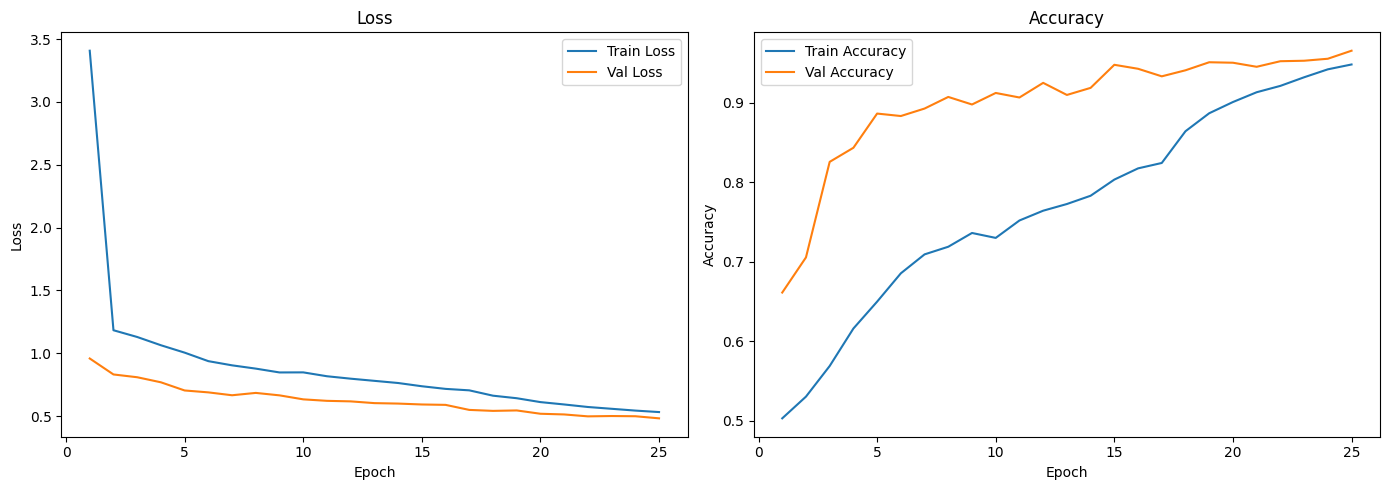

In [ ]:
#— LOSS & ACCURACY GRAPHS
import matplotlib.pyplot as plt

# Phase 1
p1_train_loss = [3.4071, 1.1827, 1.1290, 1.0633, 1.0045, 0.9367, 0.9034, 0.8773, 0.8468, 0.8474]
p1_val_loss   = [0.9579, 0.8308, 0.8087, 0.7684, 0.7034, 0.6882, 0.6653, 0.6840, 0.6645, 0.6327]
p1_train_acc  = [0.5031, 0.5304, 0.5689, 0.6160, 0.6498, 0.6854, 0.7092, 0.7188, 0.7361, 0.7299]
p1_val_acc    = [0.6612, 0.7054, 0.8255, 0.8432, 0.8862, 0.8831, 0.8925, 0.9071, 0.8976, 0.9121]

# Phase 2
p2_train_loss = [0.8166, 0.7972, 0.7800, 0.7628, 0.7370, 0.7160, 0.7044, 0.6619, 0.6417, 0.6108, 0.5920, 0.5719, 0.5576, 0.5433, 0.5315]
p2_val_loss   = [0.6209, 0.6166, 0.6027, 0.5991, 0.5919, 0.5888, 0.5487, 0.5410, 0.5445, 0.5181, 0.5126, 0.4974, 0.5000, 0.4983, 0.4816]
p2_train_acc  = [0.7518, 0.7641, 0.7725, 0.7829, 0.8032, 0.8173, 0.8241, 0.8640, 0.8866, 0.9007, 0.9130, 0.9210, 0.9318, 0.9418, 0.9479]
p2_val_acc    = [0.9064, 0.9248, 0.9096, 0.9185, 0.9475, 0.9425, 0.9330, 0.9406, 0.9507, 0.9501, 0.9450, 0.9520, 0.9526, 0.9551, 0.9652]

train_loss = p1_train_loss + p2_train_loss
val_loss   = p1_val_loss   + p2_val_loss
train_acc  = p1_train_acc  + p2_train_acc
val_acc    = p1_val_acc    + p2_val_acc

epochs = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_loss, label='Train Loss')
ax1.plot(epochs, val_loss,   label='Val Loss')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_acc, label='Train Accuracy')
ax2.plot(epochs, val_acc,   label='Val Accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()


Confusion Matrix (Test)

⏳ Loading model...
✅ Model loaded!
Found 1588 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 42s 549ms/step


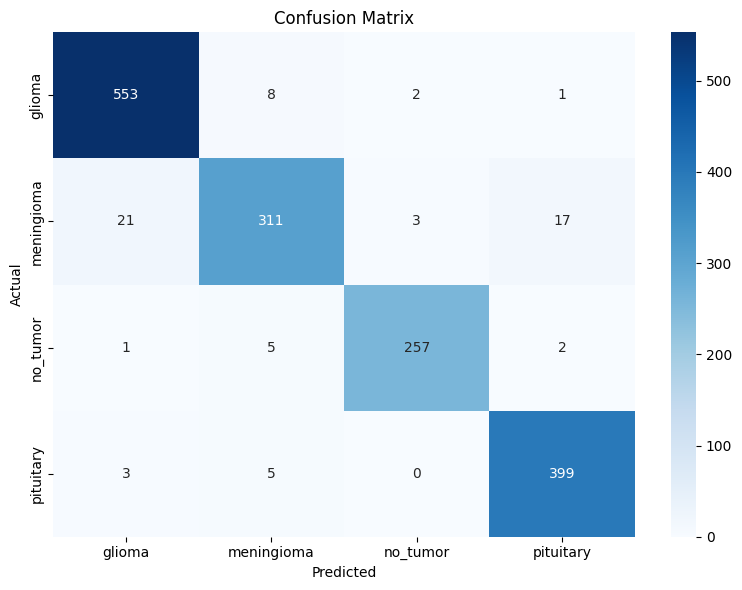

              precision    recall  f1-score   support

      glioma       0.96      0.98      0.97       564
  meningioma       0.95      0.88      0.91       352
    no_tumor       0.98      0.97      0.98       265
   pituitary       0.95      0.98      0.97       407

    accuracy                           0.96      1588
   macro avg       0.96      0.95      0.96      1588
weighted avg       0.96      0.96      0.96      1588



In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import os
import json
from tensorflow.keras.models import load_model

# Load model and metadata
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")

# Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]

# Load model
if 'model' not in locals(): # Check if model is already loaded
    print("Loading model...")
    model = load_model(MODEL_PATH)
    print(" Model loaded!")

# CELL 2 — CONFUSION MATRIX

TEST_DIR    = '/content/drive/MyDrive/MRI Imgs Split/test'

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    TEST_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=32,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Validation Evaluation

⏳ Loading model...
✅ Model loaded!
Found 1582 images belonging to 4 classes.
50/50 ━━━━━━━━━━━━━━━━━━━━ 1182s 24s/step

  CLASSIFICATION REPORT — VALIDATION SET
              precision    recall  f1-score   support

      glioma     0.9652    0.9840    0.9745       563
  meningioma     0.9721    0.8946    0.9318       351
    no_tumor     0.9774    0.9886    0.9830       263
   pituitary     0.9523    0.9852    0.9684       405

    accuracy                         0.9652      1582
   macro avg     0.9668    0.9631    0.9644      1582
weighted avg     0.9654    0.9652    0.9649      1582



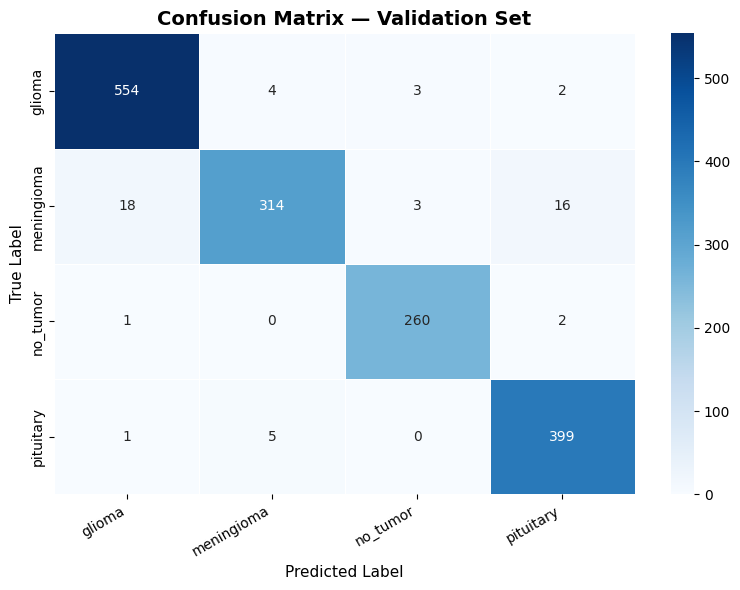

In [ ]:

# VALIDATION — CONFUSION MATRIX + CLASSIFICATION REPORT
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os # Added for os.path.join
import json # Added for json.load
from tensorflow.keras.models import load_model # Added for load_model

# Define paths and load metadata
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras") # Define MODEL_PATH

# Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES = meta["class_names"]
IMAGE_SIZE  = meta["image_size"]

# Define other necessary variables (from config cell)
VAL_DIR     = "/content/drive/MyDrive/MRI Imgs Split/val"
BATCH_SIZE  = 32

# Load the model
print("Loading model...")
model = load_model(MODEL_PATH)
print(" Model loaded!")

# ── Validation Generator (shuffle=False for correct alignment)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    VAL_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,
    shuffle=False
)

# ── Predictions
y_probs = model.predict(val_gen, verbose=1)
y_pred  = np.argmax(y_probs, axis=1)
y_true  = val_gen.classes

# ── Classification Report
print("\n" + "="*55)
print("  CLASSIFICATION REPORT — VALIDATION SET")
print("="*55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# ── Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            linewidths=0.5)
plt.title('Confusion Matrix — Validation Set', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(MODEL_OUT_DIR, "confusion_matrix_val.png"), dpi=150)
plt.show()

In [5]:
import subprocess
subprocess.run(["pip", "install", "gradio", "scipy", "-q"])

import os, json, cv2
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import gradio as gr
from PIL import Image, ImageDraw
from scipy.stats import entropy as scipy_entropy
from sklearn.metrics.pairwise import cosine_similarity
import tensorflow as tf
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.vgg16 import preprocess_input
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
    print("✅ Drive mounted")
else:
    print("✅ Drive already mounted")

# ── Paths
MODEL_OUT_DIR = "/content/drive/MyDrive/model_artifacts"
MODEL_PATH    = os.path.join(MODEL_OUT_DIR, "vgg16_final.keras")
META_PATH     = os.path.join(MODEL_OUT_DIR, "metadata.json")
FEATURES_PATH = os.path.join(MODEL_OUT_DIR, "knn_features.npy")
LABELS_PATH   = os.path.join(MODEL_OUT_DIR, "knn_labels.npy")
PATHS_PATH    = os.path.join(MODEL_OUT_DIR, "knn_paths.npy")

# ── Load metadata
with open(META_PATH) as f:
    meta = json.load(f)
CLASS_NAMES       = meta["class_names"]
IMAGE_SIZE        = meta["image_size"]
CONF_THRESHOLD    = meta["conf_threshold"]
ENTROPY_THRESHOLD = meta["entropy_threshold"]
NUM_CLASSES       = meta["num_classes"]

print("✅ Metadata loaded")

# ── Load model
print("⏳ Loading model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded!")

# ── Build feature extractor
feature_extractor = Model(
    inputs=model.inputs,
    outputs=model.get_layer("block5_pool").output
)

# ── Load KNN data
print("⏳ Loading KNN features...")
knn_features = np.load(FEATURES_PATH)
knn_labels   = np.load(LABELS_PATH)
knn_paths    = np.load(PATHS_PATH)
print(f"✅ KNN ready — {len(knn_features)} training images loaded")


# ── MRI VALIDATOR (Scoring System — v2)          ← NEW: replaced old validator
def is_valid_mri(pil_img):
    img  = np.array(pil_img.convert('RGB'))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    h, w = gray.shape
    score = 0
    reasons_failed = []

    # Check 1: Size (hard rule — instant reject if fails)
    if h < 50 or w < 50:
        return False, "Image too small (hard reject)"

    # Check 2: Dark background (3 points)
    dark_ratio = np.sum(gray < 30) / gray.size
    if dark_ratio >= 0.10:
        score += 3
    else:
        reasons_failed.append("No dark background")

    # Check 3: Structural edges (3 points)
    edges = cv2.Canny(gray, 30, 100)
    edge_ratio = np.sum(edges > 0) / edges.size
    if edge_ratio >= 0.01:
        score += 3
    else:
        reasons_failed.append("No structure/edges")

    # Check 4: Saturation (3 points) — threshold raised to 65 to allow RGB MRIs ← NEW
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    mean_saturation = np.mean(hsv[:,:,1])
    if mean_saturation <= 65:                     # ← was 40, now 65
        score += 3
    else:
        reasons_failed.append("Too colorful/saturated")

    # ── Decision: need at least 7 out of 9 to pass  ← NEW: scoring instead of all-or-nothing
    if score >= 7:
        return True, "ok"
    else:
        reason_str = "Failed: " + ", ".join(reasons_failed)
        return False, reason_str


# ══════════════════════════════════════════════════
# ── VALIDATION TEST BLOCK                         ← NEW: paste this right after is_valid_mri
#    Run this cell once to confirm validator works
# ══════════════════════════════════════════════════
print("\n── Running validation tests ──")

# Test 1: Pure black image — should FAIL (no edges, no structure)
black = Image.fromarray(np.zeros((200, 200, 3), dtype=np.uint8))
result1 = is_valid_mri(black)
print(f"Test 1 (black image)     → {result1}")
assert result1[0] == False, "❌ Test 1 failed — black image should be rejected"
print("✅ Test 1 passed")

# Test 2: Random colorful image — should FAIL (too saturated, no dark bg)
colorful = Image.fromarray(np.random.randint(100, 255, (200, 200, 3), dtype=np.uint8))
result2 = is_valid_mri(colorful)
print(f"Test 2 (colorful image)  → {result2}")
assert result2[0] == False, "❌ Test 2 failed — colorful image should be rejected"
print("✅ Test 2 passed")

# Test 3: Tiny image — should FAIL (hard reject — too small)
tiny = Image.fromarray(np.zeros((30, 30, 3), dtype=np.uint8))
result3 = is_valid_mri(tiny)
print(f"Test 3 (tiny 30x30)      → {result3}")
assert result3[0] == False, "❌ Test 3 failed — tiny image should be hard rejected"
print("✅ Test 3 passed")

#Test 4: Real MRI image — should PASS        ← replace path with your actual MRI image
real_mri = Image.open("/content/drive/MyDrive/MRI Imgs Split/test/meningioma/meningioma1855.jpg")
result4   = is_valid_mri(real_mri)
print(f"Test 4 (real MRI)        → {result4}")
assert result4[0] == True, "❌ Test 4 failed — real MRI should be accepted"
print("✅ Test 4 passed")

print("\n✅ All validation tests passed — scorer is working correctly!\n")
# ══════════════════════════════════════════════════


# ── KNN RETRIEVAL — finds top 3 most similar training images
def get_similar_images(pil_img, pred_class, top_k=3):
    img = pil_img.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = preprocess_input(np.array(img, dtype=np.float32))
    x   = np.expand_dims(arr, axis=0)

    query_feat  = feature_extractor.predict(x, verbose=0)[0].flatten()
    query_feat  = query_feat.reshape(1, -1)

    class_mask  = (knn_labels == pred_class)
    class_feats = knn_features[class_mask]
    class_paths = knn_paths[class_mask]

    sims       = cosine_similarity(query_feat, class_feats)[0]
    sorted_idx = np.argsort(sims)[::-1]

    selected       = []
    selected_feats = []

    for idx in sorted_idx:
        if len(selected) >= top_k:
            break
        candidate_feat = class_feats[idx].reshape(1, -1)
        if selected_feats:
            max_sim_to_selected = max(
                cosine_similarity(candidate_feat, sf)[0][0]
                for sf in selected_feats
            )
            if max_sim_to_selected > 0.97:
                continue
        selected.append(idx)
        selected_feats.append(candidate_feat)

    results = []
    for idx in selected:
        sim_score = float(sims[idx])
        img_path  = class_paths[idx]
        try:
            sim_img = Image.open(img_path).convert('RGB').resize((300, 300))
            results.append((sim_img, sim_score, pred_class, img_path))
        except:
            continue
    return results


# ── SIMILAR IMAGES PLOT
def make_similar_plot(similar_images, pred_class):
    n   = len(similar_images)
    fig, axes = plt.subplots(1, n, figsize=(8*n, 8))
    fig.patch.set_facecolor('#080c10')
    if n == 1:
        axes = [axes]
    title_colors = {
        "glioma"     : "#ff4444",
        "meningioma" : "#4499ff",
        "pituitary"  : "#ffcc00",
        "notumor"    : "#00ff99",
    }
    tc = title_colors.get(pred_class.lower(), "#ffffff")
    for i, (img, score, label, img_path) in enumerate(similar_images):
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(
            f"Match #{i+1}  |  {score*100:.1f}% similar",
            color=tc, fontsize=13, fontweight='bold', pad=12
        )
        filename = os.path.basename(img_path)
        axes[i].set_xlabel(
            f"{filename}  |  Class: {label.upper()}" +
           (f"\n\nTop 3 Similar Training Images — Confirmed {pred_class.upper()}" if i == 1 else ""),
            color='#ffffff', fontsize=10, fontweight='bold', labelpad=12
        )
        axes[i].set_xticks([])
        axes[i].set_yticks([])
        for sp in axes[i].spines.values():
            sp.set_edgecolor(tc)
            sp.set_linewidth(2)
    plt.tight_layout(pad=2.0)
    plt.subplots_adjust(top=0.92, bottom=0.15)
    return fig


# ── PLOTS
def make_rejection_plot(reason):
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.patch.set_facecolor('#080c10')
    ax.set_facecolor('#080c10')
    ax.text(0.5, 0.46, 'REJECTED', fontsize=24, ha='center', va='center',
            transform=ax.transAxes, fontweight='bold', color='#ff3333')
    ax.text(0.5, 0.30, 'Please upload a valid Brain MRI', fontsize=10,
            ha='center', va='center', transform=ax.transAxes, color='#778899')
    ax.text(0.5, 0.14, reason, fontsize=8.5, ha='center', va='center',
            transform=ax.transAxes, color='#ff7777', style='italic')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_edgecolor('#ff3333')
        sp.set_linewidth(2)
    plt.tight_layout()
    return fig


def make_prediction_plot(probs, prediction):
    fig, ax = plt.subplots(figsize=(5, 4))
    fig.patch.set_facecolor('#080c10')
    ax.set_facecolor('#0d1117')
    colors = ['#00ff99' if c == prediction else '#1e2d3d' for c in CLASS_NAMES]
    bars   = ax.barh(CLASS_NAMES, probs, color=colors, edgecolor='#1a2a3a', height=0.5)
    ax.set_xlim(0, 1.05)                          # ← was 1.15, now 1.05 (no % text space needed)
    ax.set_xlabel('Confidence', color='#8899aa', fontsize=9)
    ax.set_title('Class Probabilities', color='#ccddee', fontsize=11, pad=8)
    ax.tick_params(colors='#8899aa')
    for sp in ax.spines.values():
        sp.set_edgecolor('#1a2a3a')
    # ← REMOVED: percentage text loop (the for bar, prob in zip block) ← NEW
    plt.tight_layout()
    return fig


# ── CLASS EXPLANATIONS
CLASS_EXPLANATIONS = {
    "glioma": (
        "GLIOMA DETECTED\n"
        "─────────────────────────────────────\n"
        "A malignant brain tumor growing from\n"
        "glial cells, often with irregular edges.\n\n"
        "1 Irregular edges with no clear boundary\n"
        "2 Mixed bright/dark areas inside tumor\n"
        "3 Bright swelling ring around the mass\n\n"
        "─────────────────────────────────────\n"
        "Severity  :  HIGH\n"
        "Treatment :  Surgery + Radiation + Chemo"
    ),
    "meningioma": (
        "MENINGIOMA DETECTED\n"
        "─────────────────────────────────────\n"
        "A tumor growing from the protective\n"
        "layers (meninges) covering the brain.\n\n"
        "1 Round, well-defined shape with clear borders\n"
        "2 Uniform brightness — no necrosis inside\n"
        "3 Attached to outer brain lining, not tissue\n\n"
        "─────────────────────────────────────\n"
        "Severity  :  MODERATE\n"
        "Treatment :  Monitoring or Surgery"
    ),
    "notumor": (
        "NO TUMOR DETECTED\n"
        "─────────────────────────────────────\n"
        "The brain scan appears normal with\n"
        "no visible signs of any tumor or mass.\n\n"
        "1 No abnormal mass or lesion found\n"
        "2 Brain structure appears symmetric\n"
        "3 No swelling or edema detected\n\n"
        "─────────────────────────────────────\n"
        "Severity  :  NONE\n"
        "Note      :  Always confirm with radiologist"
    ),
    "pituitary": (
        "PITUITARY TUMOR DETECTED\n"
        "─────────────────────────────────────\n"
        "A tumor in the pituitary gland located\n"
        "at the base of the brain.\n\n"
        "1 Abnormal mass at base of the brain\n"
        "2 Pressure effect on surrounding areas\n"
        "3 Possible compression of optic nerves\n\n"
        "Severity  :  MODERATE\n"
        "Treatment :  Medication or Surgery"
    ),
}


# ── CORE INFERENCE
CONF_THRESHOLD    = 0.65
ENTROPY_THRESHOLD = 0.70

def run_inference(pil_img):
    if pil_img is None:
        return "—", "", None, None

    valid, reason = is_valid_mri(pil_img)
    if not valid:
        return "REJECTED", "Please upload a valid Brain MRI scan.", make_rejection_plot(reason), None

    img = pil_img.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    arr = preprocess_input(np.array(img, dtype=np.float32))
    x   = np.expand_dims(arr, axis=0)

    probs    = model.predict(x, verbose=0)[0]
    top_idx  = int(np.argmax(probs))
    top_conf = float(probs[top_idx])
    pred     = CLASS_NAMES[top_idx]

    norm_ent = scipy_entropy(probs, base=2) / np.log2(NUM_CLASSES)
    if norm_ent > ENTROPY_THRESHOLD:
        reason = f"Model uncertain (entropy={norm_ent:.2f})"
        return "REJECTED", "Model is uncertain about this image.", make_rejection_plot(reason), None

    if top_conf < CONF_THRESHOLD:
        reason = f"Low confidence ({top_conf*100:.1f}%)"
        return "REJECTED", "Model confidence too low for this image.", make_rejection_plot(reason), None

    prob_plot   = make_prediction_plot(probs, pred)
    similar     = get_similar_images(pil_img, pred)
    sim_plot    = make_similar_plot(similar, pred) if similar else None
    explanation = CLASS_EXPLANATIONS.get(pred.lower(), "No explanation available.")

    return f"✅  {pred.upper()}", explanation, prob_plot, sim_plot


# ── GRADIO UI
with gr.Blocks(
    theme=gr.themes.Base(primary_hue="emerald", neutral_hue="slate"),
    css="""
        .gradio-container { max-width: 720px; margin: auto; font-family: monospace; }
        #title    { text-align:center; color:#00ff99; font-size:1.9em; font-weight:bold; padding:18px 0 2px; }
        #subtitle { text-align:center; color:#445566; font-size:0.8em; margin-bottom:20px; letter-spacing:0.08em; text-transform:uppercase; }
        #pred_box textarea { font-size:1.4em !important; font-weight:bold !important; text-align:center; color:#00ff99 !important; }
        #run_btn  { height: 48px !important; font-size:1em !important; font-weight:bold !important; margin-top:8px; }
    """
) as demo:

    gr.Markdown("<div id='title'>🧠 Brain Tumor MRI Classifier</div>")

    img_input = gr.Image(type="pil", label="📂 Upload MRI Image", height=300)
    run_btn   = gr.Button("Run Inference", variant="primary", size="lg", elem_id="run_btn")
    out_pred  = gr.Textbox(label="Prediction", interactive=False, elem_id="pred_box", lines=1)
    out_explain = gr.Textbox(label="Why this prediction?", interactive=False, lines=13, max_lines=16)
    out_plot  = gr.Plot(label="Class Probability Breakdown", show_label=True)
    out_sim   = gr.Plot(label="Top 3 Similar Training Images (KNN)", show_label=False)

    run_btn.click(fn=run_inference, inputs=[img_input],
                  outputs=[out_pred, out_explain, out_plot, out_sim])
    img_input.change(fn=run_inference, inputs=[img_input],
                     outputs=[out_pred, out_explain, out_plot, out_sim])

demo.launch(share=True, debug=False)
print("\n✅ UI live — use the link above")

✅ Drive already mounted
✅ Metadata loaded
⏳ Loading model...
✅ Model loaded!
⏳ Loading KNN features...
✅ KNN ready — 7390 training images loaded

── Running validation tests ──
Test 1 (black image)     → (False, 'Failed: No structure/edges')
✅ Test 1 passed
Test 2 (colorful image)  → (False, 'Failed: No dark background, Too colorful/saturated')
✅ Test 2 passed
Test 3 (tiny 30x30)      → (False, 'Image too small (hard reject)')
✅ Test 3 passed
Test 4 (real MRI)        → (True, 'ok')
✅ Test 4 passed

✅ All validation tests passed — scorer is working correctly!



/tmp/ipykernel_2399/1012792346.py:351: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_2399/1012792346.py:351: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08b748c749e3c8df08.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ UI live — use the link above
